In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

os.makedirs('output', exist_ok=True)
np.set_printoptions(precision=3, suppress=True)

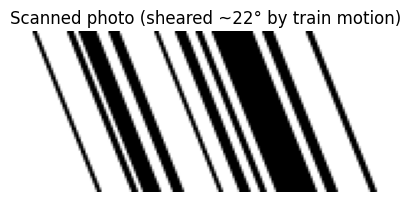

In [2]:
def make_barcode(w=140, h=70, n_bars=28, seed=3):
    """Synthetic barcode: random-width vertical black/white bars."""
    rng = np.random.default_rng(seed)
    img = np.full((h, w), 255, dtype=np.uint8)
    x = 4
    while x < w - 4:
        bar_w = int(rng.integers(2, 6))
        if rng.random() > 0.5:
            img[:, x:x + bar_w] = 0
        x += bar_w
    return img

barcode = make_barcode()
cv2.imwrite('data/barcode.png', barcode)
h0, w0 = barcode.shape

alpha_slant = np.deg2rad(22)
k_slant = np.tan(alpha_slant)
Sh_slant = np.array([[1, k_slant], [0, 1]])
slant_extra_w = int(np.ceil(abs(k_slant) * h0))
sw = w0 + slant_extra_w
slanted = cv2.warpAffine(barcode, np.hstack([Sh_slant, [[0], [0]]]),
                          (sw, h0), borderValue=255)

plt.figure(figsize=(5, 3))
plt.imshow(slanted, cmap='gray')
plt.title('Scanned photo (sheared ~22° by train motion)')
plt.axis('off')
plt.savefig('output/t3_00_sheared_input.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
h1, w1 = slanted.shape
k = -k_slant

Sh = np.array([
    [1.0, k],
    [0.0, 1.0]
])
print('Shear correction matrix Sh =\n', Sh)

extra_w = int(np.ceil(abs(k) * h1))
new_w, new_h = w1 + extra_w, h1
print(f'Corrected canvas width: {new_w} (input was {w1}, padded by {extra_w})')

t = np.array([extra_w if k < 0 else 0, 0])
M = np.hstack([Sh, t.reshape(2, 1)])
print('Full 2x3 affine matrix M =\n', M)

straightened = cv2.warpAffine(slanted, M, (new_w, new_h), borderValue=255)

fig, axes = plt.subplots(2, 1, figsize=(7, 5))
axes[0].imshow(slanted, cmap='gray')
axes[0].set_title(f'Sheared input {w1}x{h1}')
axes[0].axis('off')
axes[1].imshow(straightened, cmap='gray')
axes[1].set_title(f'Straightened, bars now vertical {new_w}x{new_h}')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('output/t3_01_straightened.png', bbox_inches='tight', dpi=150)
plt.show()

Shear correction matrix Sh =
 [[ 1.    -0.404]
 [ 0.     1.   ]]
Corrected canvas width: 198 (input was 169, padded by 29)
Full 2x3 affine matrix M =
 [[ 1.    -0.404 29.   ]
 [ 0.     1.     0.   ]]
